In [1]:
from collections.abc import Sequence
from pathlib import Path

import h5py
import matplotlib.pyplot as plt
import numpy as np
import pyvista as pv
import skimage
from desmin_reconstruction.plotting.lineplots import line_and_bandplot
from desmin_reconstruction.utils.array import midpoints
from einops import rearrange
from jaxtyping import Bool, Float, Int, Shaped
from tqdm import tqdm


pv.set_jupyter_backend("static")

datadir = Path("../data/SIM")


COLOR_DICT = {"desmin": "#FF0000", "actinin": "#00FF00", "actin": "#0000FF"}
LABEL_DICT = {"desmin": "Desmin", "actin": "Actin", "actinin": "α-actinin"}


def read_SIM_data(filepath: Path | str):
    f = h5py.File(filepath)
    data = f["Data"][:]
    pixel_sizes = f["Data"].attrs["pixel_sizes"]
    dtype = data.dtype
    if dtype.kind == "u":
        data = data / np.iinfo(dtype).max
    return data, pixel_sizes


In [2]:
data_full, pixel_sizes = read_SIM_data(datadir / "alpha-actinin/Image2_SIM2.h5")
print(pixel_sizes)
data = data_full[:, 0:12, 2000 - 768 : 2000, 0:768]
data.shape

[0.12593877 0.01565149 0.01565149]


(2, 12, 768, 768)

In [3]:
grids_subset = []
img_data = rearrange(data, "C Z Y X->C X Y Z")
for img_channel in img_data:
    grid = pv.ImageData(
        dimensions=np.array(img_channel.shape) + 1,
        spacing=pixel_sizes[::-1],
        # origin=(bbox.x0, bbox.y0, 0),
    )
    grid.cell_data["data"] = img_channel.flatten(order="F")
    grids_subset.append(grid)

2026-07-04 00:35:07.724 (  11.876s) [    14E4CD02F740]vtkXOpenGLRenderWindow.:1416  WARN| bad X server connection. DISPLAY=


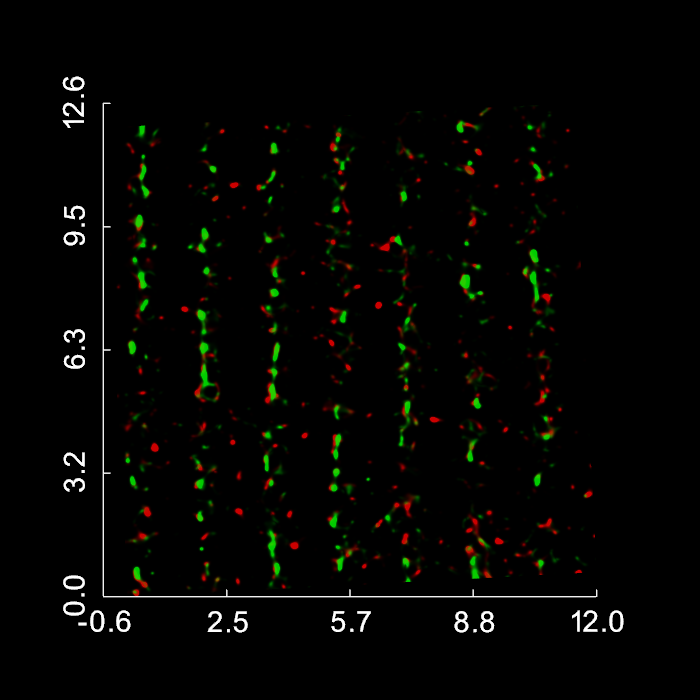

In [4]:
pl = pv.Plotter(notebook=True, window_size=(700, 700))
pl.subplot(0, 0)
actor = pl.add_volume(
    grids_subset[0].rotate_z(3),
    cmap=["#FF0000"],
    opacity=[0.0, 0.2, 0.8],
    clim=(0, 0.2),
    blending="maximum",
    show_scalar_bar=False,
)
actor.prop.interpolation_type = "linear"
actor = pl.add_volume(
    grids_subset[1].rotate_z(3),
    cmap=["#00FF00"],
    opacity=[0.0, 0.2, 0.8],
    clim=(0, 0.2),
    # opacity_unit_distance=1.5,
    blending="maximum",
    show_scalar_bar=False,
)
actor.prop.interpolation_type = "linear"
pl.set_background(color="black")
pl.enable_parallel_projection()

pl.view_xy()
axis = pl.show_bounds(
    color="white",
    # axes_ranges=[0, 16, 0, 16, 0, 0],
    grid=None,
    bold=False,
    font_size=22,
    font_family="arial",
    padding=0.0,
    use_3d_text=False,
    show_zaxis=False,
    xtitle="",
    ytitle="",
    ztitle="",
)
pl.show()
# pl.save_graphic("../figures/fig_4/4b/overlay_xy.svg")

2026-06-30 19:17:21.291 (  10.897s) [    1494B8BDA740] vtkEGLRenderWindow.cxx:674   WARN| vtkEGLRenderWindow (0x7a454f0): Unable to eglMakeCurrent: 12291
2026-06-30 19:17:21.311 (  10.917s) [    1494B8BDA740] vtkEGLRenderWindow.cxx:674   WARN| vtkEGLRenderWindow (0x5fce9c0): Unable to eglMakeCurrent: 12291
2026-06-30 19:17:24.804 (  14.409s) [    1494B8BDA740] vtkEGLRenderWindow.cxx:674   WARN| vtkEGLRenderWindow (0x7a454f0): Unable to eglMakeCurrent: 12291


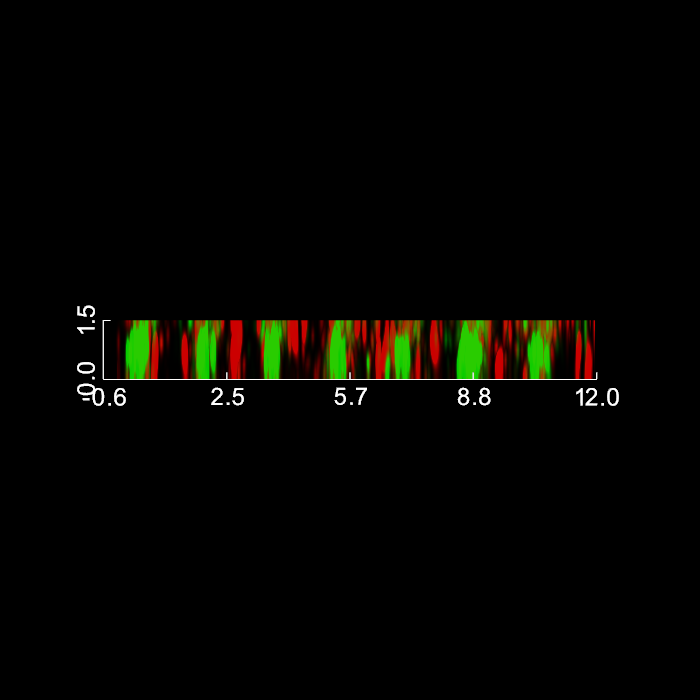

In [5]:
pl = pv.Plotter(notebook=True, window_size=(700, 700))
actor = pl.add_volume(
    grids_subset[0].rotate_z(3),
    cmap=["#FF0000"],
    opacity=[0.0, 0.2, 0.8],
    clim=(0, 0.20),
    blending="maximum",
    show_scalar_bar=False,
)
actor.prop.interpolation_type = "linear"
actor = pl.add_volume(
    grids_subset[1].rotate_z(3),
    cmap=["#00FF00"],
    opacity=[0.0, 0.2, 0.8],
    clim=(0, 0.20),
    # opacity_unit_distance=1.5,
    blending="maximum",
    show_scalar_bar=False,
)
actor.prop.interpolation_type = "linear"
pl.set_background(color="black")
pl.enable_parallel_projection()

pl.view_xz()
axis = pl.show_bounds(
    color="white",
    # axes_ranges=[0, 16, 0, 16, 0, 0],
    grid=None,
    bold=False,
    font_size=22,
    font_family="arial",
    padding=0.0,
    use_3d_text=False,
    show_zaxis=False,
    n_zlabels=2,
    xtitle="",
    ytitle="",
    ztitle="",
)
pl.show()
# pl.save_graphic("../figures/fig_4/4b/overlay_xz.svg")

In [6]:
data.shape

(2, 12, 768, 768)

In [6]:
kernel_size = (data[0].shape[0] // 10, data[0].shape[1] // 5, data[0].shape[2] // 5)
print(kernel_size)
data = [
    skimage.exposure.equalize_adapthist(d, kernel_size, np.percentile(d.flatten(), 99))
    for d in data
]


(1, 153, 153)


In [6]:
z_ind = 5  # 0:12
img_orig = data[1][z_ind]

In [7]:
img_orig.shape

(768, 768)

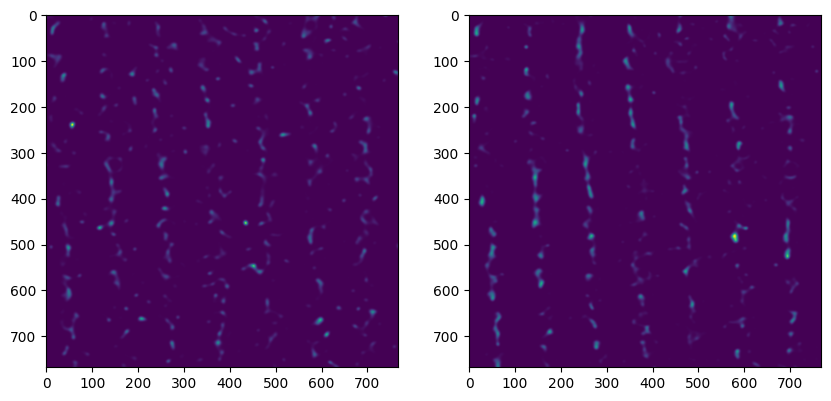

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(10, 6))
for i, ax in enumerate(axes):
    ax.imshow(data[i][z_ind])

In [9]:
def detect_Z_lines(
    img: Float[np.ndarray, "X Y"],
    blur_sigma: tuple[int, int] = (40, 5),
    ridge_sigmas: int | Sequence[int] = range(15, 20),
    lower_thres_ratio: float = 0.4,
) -> tuple[Bool[np.ndarray, "X Y"], dict[str, Shaped[np.ndarray, "X Y"]]]:
    blurred = skimage.filters.gaussian(img, blur_sigma)
    ridges = skimage.filters.sato(blurred, sigmas=ridge_sigmas, black_ridges=False)
    thres = skimage.filters.threshold_otsu(ridges)
    binarized = skimage.filters.apply_hysteresis_threshold(
        ridges, lower_thres_ratio * thres, thres
    )
    skele = skimage.morphology.medial_axis(binarized)

    metadata = {"blurred": blurred, "ridges": ridges, "binarized": binarized}
    return skele, metadata

In [12]:
np.max(img_orig)

np.float64(0.8204470893415732)

In [44]:
import matplotlib.colors as mcolors
def array_to_greens(data, vmin: float|None=None, vmax: float|None=None):
    normalizer = mcolors.Normalize(vmin=vmin, vmax=vmax)
    data=normalizer(data.astype(float))
    return np.stack((np.zeros_like(data),np.ones_like(data),np.zeros_like(data),data), axis=-1)

In [45]:
rgb = np.stack((np.zeros_like(img_orig),np.ones_like(img_orig),np.zeros_like(img_orig),img_orig), axis=-1)
rgb

array([[[0.00000000e+00, 1.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [0.00000000e+00, 1.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [0.00000000e+00, 1.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        ...,
        [0.00000000e+00, 1.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [0.00000000e+00, 1.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [0.00000000e+00, 1.00000000e+00, 0.00000000e+00, 0.00000000e+00]],

       [[0.00000000e+00, 1.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [0.00000000e+00, 1.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [0.00000000e+00, 1.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        ...,
        [0.00000000e+00, 1.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [0.00000000e+00, 1.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [0.00000000e+00, 1.00000000e+00, 0.00000000e+00, 0.00000000e+00]],

       [[0.00000000e+00, 1.00000000e+00, 0.00000000e+00, 1.52590219e-05],
        

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..2.7348236311385774].


Text(0.02, 0.5, 'y (μm)')

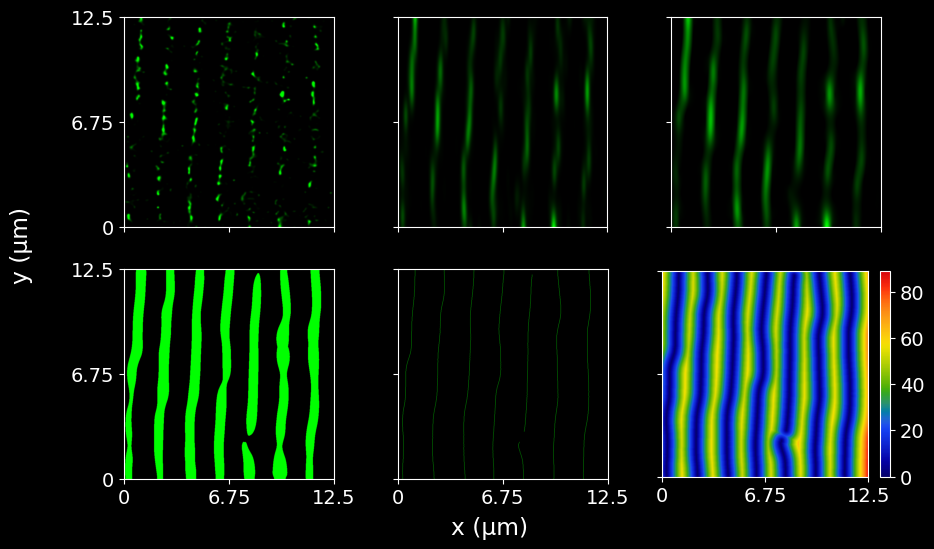

In [ ]:
import scipy.ndimage as scndimage
import colorcet as cc
plt.style.use("dark_background")
plt.rc("font",size=14)

skele, metadata = detect_Z_lines(img_orig)
dists = scndimage.distance_transform_edt(np.logical_not(skele))

titles = ["Original", "Anisotropic blur", "Ridge detection", "Ridge binarized", "Z line skeleton", "Z line distances"]
fig, axes = plt.subplots(2, 3, figsize=(10, 6), sharex=True, sharey=True)
axes=axes.flat
axes[0].imshow(array_to_greens(img_orig, vmax=0.3), origin="lower")
axes[1].imshow(array_to_greens(metadata["blurred"]), origin="lower")
axes[2].imshow(array_to_greens(metadata["ridges"]), origin="lower")
axes[3].imshow(array_to_greens(metadata["binarized"]), origin="lower")
axes[4].imshow(array_to_greens(skele), origin="lower")
p=axes[5].imshow(dists, cmap=cc.cm.rainbow4, origin="lower")
fig.colorbar(p, ax=axes[5], fraction=0.045)
for ax in axes:
    ax.set_xticks([0, img_orig.shape[0]//2, img_orig.shape[0]], [0, 6.75, 12.5])
    ax.set_yticks([0, img_orig.shape[1]//2, img_orig.shape[1]], [0, 6.75, 12.5])

fig.supxlabel("x (μm)")
fig.supylabel("y (μm)")



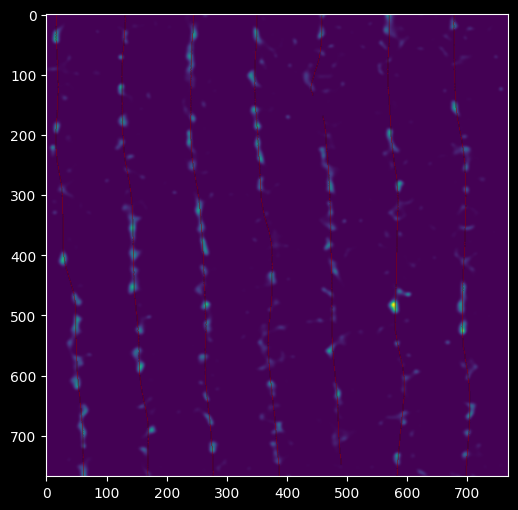

In [38]:
fig, ax = plt.subplots(1, 1, figsize=(6, 6))

ax.imshow(
    img_orig,
)
ax.imshow(np.ma.masked_where(skele == 0, skele), alpha=0.9, cmap="autumn")

In [13]:
def binarize_z_slice(z_slice):
    bin = z_slice >= skimage.filters.threshold_otsu(z_slice)
    return skimage.morphology.binary_opening(bin, skimage.morphology.disk(3))

In [ ]:

binar_actinin = binarize_z_slice(data[1][z_ind])
binar_desmin = binarize_z_slice(data[0][z_ind])

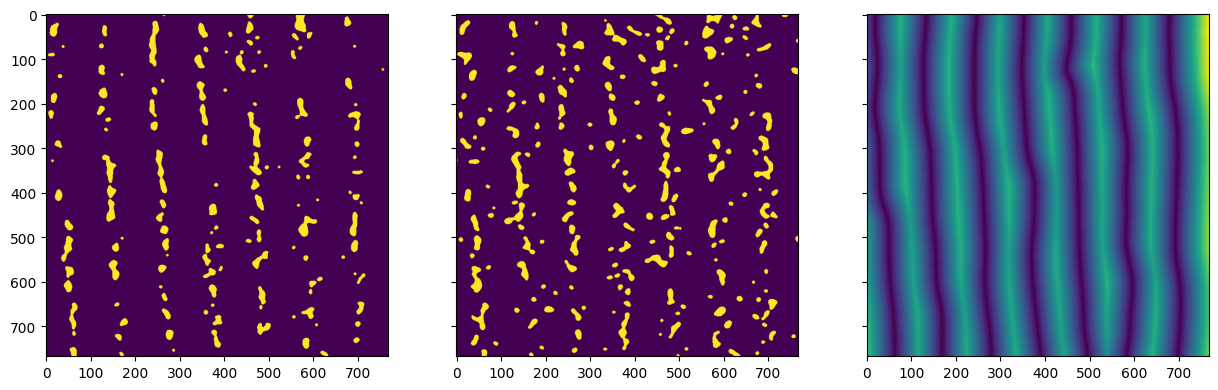

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 6), sharex=True, sharey=True)
axes[2].imshow(dists)
axes[0].imshow(binar_actinin)
axes[1].imshow(binar_desmin)

In [16]:
def connected_to_boundary(region: Bool[np.ndarray, "X Y"], axis: int = 0) -> bool:
    """For a binary array indicating a segmented object and the background, determine
    if the object touches the image boundary along axis.

    This is done by projecting the region along the axis of interest, then checking
    both ends of the projected binary array."""
    projection = np.any(region, axis=axis)
    return projection[0] or projection[-1]


def filter_outliers(
    x: Float[np.ndarray, " N"], lower=0.5, higher: float = 1.5
) -> Float[np.ndarray, " M"]:
    median = np.nanmedian(x)
    return x[np.logical_and(x > 0.5 * median, x < 1.5 * median)]


def estimate_mean_sarcomere_width(
    z_lines: Bool[np.ndarray, "X Y"],
) -> tuple[Float[np.ndarray, ""], Int[np.ndarray, "X Y"]]:
    """Given a binary array marking the Z line positions, estimate the mean width of the
    sarcomeres in the image.

    Assumes that the Z lines are oriented along the Y axis, dividing the imaged region
    into banded partitions. Some imperfects in the Z lines are tolerated, as too wide or
    too narrow regions are excluded during averaging."""

    region_ids, num_regions = skimage.measure.label(
        z_lines, background=True, connectivity=1, return_num=True
    )
    widths = []
    for i in range(1, num_regions + 1):
        region = region_ids == i
        if not connected_to_boundary(region, axis=0):
            widths.append(np.mean(np.sum(region, axis=1)))
    return np.mean(filter_outliers(np.asarray(widths))), region_ids

In [17]:
width, labeled = estimate_mean_sarcomere_width(skele)
width

np.float64(108.38758680555554)

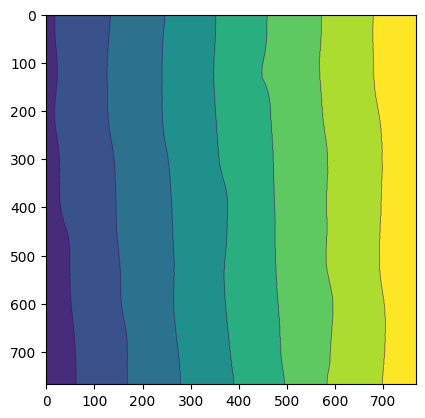

In [18]:
plt.imshow(labeled)

In [19]:
dists = []
desmin_weights = []
actinin_weights = []
sarco_widths = []
for z_ind in tqdm(range(12)):
    slice_desmin, slice_actinin = data[0][z_ind], data[1][z_ind]
    z_lines = detect_Z_lines(slice_actinin)[0]

    for roi_ind in range(9):
        z_lines_roi = rearrange(z_lines, "(Ny Y) (Nx X) -> (Ny Nx) Y X", Ny=3, Nx=3)[
            roi_ind
        ]

        desmin_roi = rearrange(
            slice_desmin, "(Ny Y) (Nx X) -> (Ny Nx) Y X", Ny=3, Nx=3
        )[roi_ind]
        actinin_roi = rearrange(
            slice_actinin, "(Ny Y) (Nx X) -> (Ny Nx) Y X", Ny=3, Nx=3
        )[roi_ind]

        sarco_width = estimate_mean_sarcomere_width(z_lines_roi)[0]
        sarco_widths.append(sarco_width)
        z_dists = scndimage.distance_transform_edt(
            np.logical_not(z_lines_roi)
        )  # / sarco_width
        dists.append(z_dists.flatten())
        desmin_weights.append(
            (np.ones_like(desmin_roi) * binarize_z_slice(desmin_roi)).flatten()
        )
        actinin_weights.append(
            (np.ones_like(actinin_roi) * binarize_z_slice(actinin_roi)).flatten()
        )
    # desmin_weights.append(binarize_z_slice(slice_desmin).flatten())
    # actinin_weights.append(binarize_z_slice(slice_actinin).flatten())


  0%|          | 0/12 [00:00<?, ?it/s]/home/jhko725/projects/desmin_reconstruction/.venv/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/jhko725/projects/desmin_reconstruction/.venv/lib/python3.12/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
100%|██████████| 12/12 [00:53<00:00,  4.50s/it]


In [20]:
sarco_width_all = rearrange(np.asarray(sarco_widths), "(Z ROI) -> ROI Z", Z=12)
sarco_width_all

array([[221.13671875, 221.19921875, 110.59179688, 110.47070312,
        110.24414062, 109.94921875, 109.62304688, 109.27734375,
        108.84179688, 108.60742188, 108.69140625, 108.64453125],
       [104.625     , 104.625     , 104.6484375 , 105.07421875,
        105.7265625 , 107.26953125, 109.234375  , 110.71875   ,
        111.7578125 , 111.60546875, 110.54296875, 109.7578125 ],
       [109.06640625, 109.30078125, 109.7421875 , 110.22265625,
        110.8125    , 111.0859375 , 111.109375  , 110.8671875 ,
        112.03515625, 113.64453125, 114.80859375, 116.1875    ],
       [107.94140625, 107.98046875, 108.25390625, 108.62109375,
        109.0859375 , 109.49609375, 109.4765625 , 108.9296875 ,
        108.2109375 , 107.37109375, 106.515625  , 106.77734375],
       [102.8203125 , 102.9765625 , 103.29296875, 103.33203125,
        103.09375   , 103.0625    , 103.19921875, 103.48046875,
        104.06640625, 104.6796875 , 105.04296875, 107.25976562],
       [110.31640625, 110.25      ,

In [21]:
sarco_width_total = [np.mean(filter_outliers(s)) for s in sarco_width_all]
dists_total = rearrange(np.asarray(dists), "(Z ROI) N -> ROI (Z N)", Z=12)
desmin_total = rearrange(np.asarray(desmin_weights), "(Z ROI) N -> ROI (Z N)", Z=12)
actinin_total = rearrange(np.asarray(actinin_weights), "(Z ROI) N -> ROI (Z N)", Z=12)

desmin_counts = [
    np.histogram(d / s, bins=np.linspace(0, 0.5, 25), weights=w, density=True)[0]
    for d, w, s in zip(dists_total, desmin_total, sarco_width_total)
]
actinin_counts = [
    np.histogram(d / s, bins=np.linspace(0, 0.5, 25), weights=w, density=True)[0]
    for d, w, s in zip(dists_total, actinin_total, sarco_width_total)
]

(0.0, 15.5)

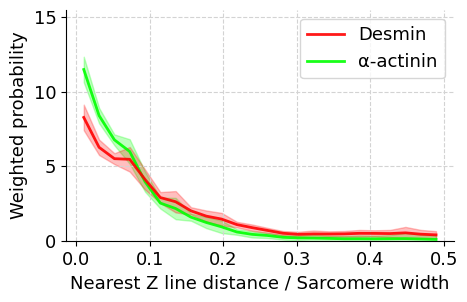

In [22]:
plt.rc("font", size=13)
fig, ax = plt.subplots(1, 1, figsize=(5, 3))
ax = line_and_bandplot(
    ax,
    midpoints(np.linspace(0, 0.5, 25)),
    np.mean(actinin_counts, axis=0),
    np.std(desmin_counts, axis=0),
    color=COLOR_DICT["actinin"],
    linewidth=2.0,
    label=LABEL_DICT["actinin"],
    alpha=0.9,
    alpha_band=0.25,
)

ax = line_and_bandplot(
    ax,
    midpoints(np.linspace(0, 0.5, 25)),
    np.mean(desmin_counts, axis=0),
    np.std(desmin_counts, axis=0),
    color=COLOR_DICT["desmin"],
    linewidth=2.0,
    label=LABEL_DICT["desmin"],
    alpha=0.9,
    alpha_band=0.25,
)


ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(ls="--", color="lightgray")
ax.set_xlabel("Nearest Z line distance / Sarcomere width")
ax.set_ylabel("Weighted probability")
h, l = ax.get_legend_handles_labels()
ax.legend(h[::-1], l[::-1])
ax.set_ylim((0.0, 15.5))
# fig.savefig("../figures/fig_4/4c.svg", dpi=500, bbox_inches="tight")

In [23]:
dists = []
desmin_weights = []
actinin_weights = []
for z_ind in tqdm(range(12)):
    slice_desmin, slice_actinin = data[0][z_ind], data[1][z_ind]
    z_lines = detect_Z_lines(slice_actinin)[0]
    sarco_width = estimate_mean_sarcomere_width(z_lines)[0]

    print(z_ind, sarco_width)
    z_dists = (
        scndimage.distance_transform_edt(np.logical_not(z_lines)) / sarco_width
    )  # / sarco_width
    dists.append(z_dists.flatten())
    desmin_weights.append(
        (np.ones_like(slice_desmin) * binarize_z_slice(slice_desmin)).flatten()
    )
    actinin_weights.append(
        (np.ones_like(slice_actinin) * binarize_z_slice(slice_actinin)).flatten()
    )
    # desmin_weights.append(binarize_z_slice(slice_desmin).flatten())
    # actinin_weights.append(binarize_z_slice(slice_actinin).flatten())


  8%|▊         | 1/12 [00:04<00:49,  4.49s/it]

0 107.34082031250001


 17%|█▋        | 2/12 [00:08<00:44,  4.47s/it]

1 107.36686197916667


 25%|██▌       | 3/12 [00:13<00:40,  4.48s/it]

...

9 108.30447048611113


 92%|█████████▏| 11/12 [00:49<00:04,  4.48s/it]

10 108.28993055555554


100%|██████████| 12/12 [00:53<00:00,  4.48s/it]

11 108.34960937500001


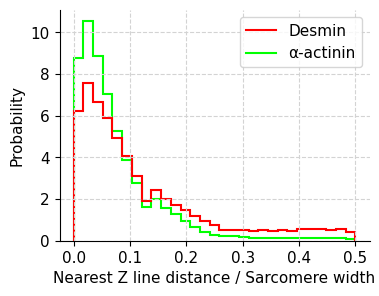

In [26]:
plt.rc("font", size=11)
fig, ax = plt.subplots(1, 1, figsize=(4, 3))
ax.stairs(
    *np.histogram(
        np.concatenate(dists, axis=0),
        bins=np.linspace(0, 0.5, 30),
        weights=np.concatenate(actinin_weights, axis=0),
        density=True,
    ),
    color=COLOR_DICT["actinin"],
    linewidth=1.5,
    label=LABEL_DICT["actinin"],
)

ax.stairs(
    *np.histogram(
        np.concatenate(dists, axis=0),
        bins=np.linspace(0, 0.5, 30),
        weights=np.concatenate(desmin_weights, axis=0),
        density=True,
    ),
    color=COLOR_DICT["desmin"],
    linewidth=1.5,
    label=LABEL_DICT["desmin"],
)


ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(ls="--", color="lightgray")
ax.set_xlabel("Nearest Z line distance / Sarcomere width")
ax.set_ylabel("Probability")
h, l = ax.get_legend_handles_labels()
ax.legend(h[::-1], l[::-1])
fig.savefig("../figures/fig_4/4c.svg", dpi=500, bbox_inches="tight")